In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# Plot styling
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

print('All libraries imported successfully!')

All libraries imported successfully!


In [3]:
data = {
    'Year': list(range(1960, 2023)),
    'GDP_USD_Billion': [
        37.03, 39.23, 42.10, 45.60, 49.87, 53.91, 57.61, 62.49, 67.97, 73.44,
        80.11, 87.05, 93.42, 101.28, 109.78, 118.67, 128.50, 140.89, 152.43, 168.03,
        187.52, 206.44, 226.17, 249.64, 271.03, 295.48, 318.80, 342.08, 374.03, 411.83,
        460.18, 505.60, 545.08, 576.23, 614.40, 660.85, 703.93, 742.93, 808.42, 880.96,
        963.07, 1026.49, 1096.57, 1191.88, 1302.98, 1415.24, 1529.40, 1653.96, 1791.59,
        1963.57, 2102.39, 2274.06, 2389.20, 2502.27, 2651.47, 2812.57, 2996.50, 3173.40,
        2702.93, 3176.30, 3201.47, 3534.74, 3385.09
    ]
}

df = pd.DataFrame(data)

# Calculate GDP Growth Rate (%)
df['GDP_Growth_Rate'] = df['GDP_USD_Billion'].pct_change() * 100
df = df.dropna().reset_index(drop=True)

print(f'Dataset shape: {df.shape}')
print(f'Years covered: {df.Year.min()} to {df.Year.max()}')
df.head(10)

Dataset shape: (62, 3)
Years covered: 1961 to 2022


,Year,GDP_USD_Billion,GDP_Growth_Rate
0,1961,39.23,5.941129
1,1962,42.10,7.315830
2,1963,45.60,8.313539
3,1964,49.87,9.364035
4,1965,53.91,8.101063
5,1966,57.61,6.863291
6,1967,62.49,8.470752
7,1968,67.97,8.769403
8,1969,73.44,8.047668
9,1970,80.11,9.082244


In [4]:
print('=== Dataset Summary ===')
print(df.describe().round(2))

=== Dataset Summary ===
          Year  GDP_USD_Billion  GDP_Growth_Rate
count    62.00            62.00            62.00
mean   1991.50           998.24             7.63
std      18.04          1080.79             3.93
min    1961.00            39.23           -14.83
25%    1976.25           131.60             6.84
50%    1991.50           525.34             8.24
75%    2006.75          1622.82             9.26
max    2022.00          3534.74            17.51


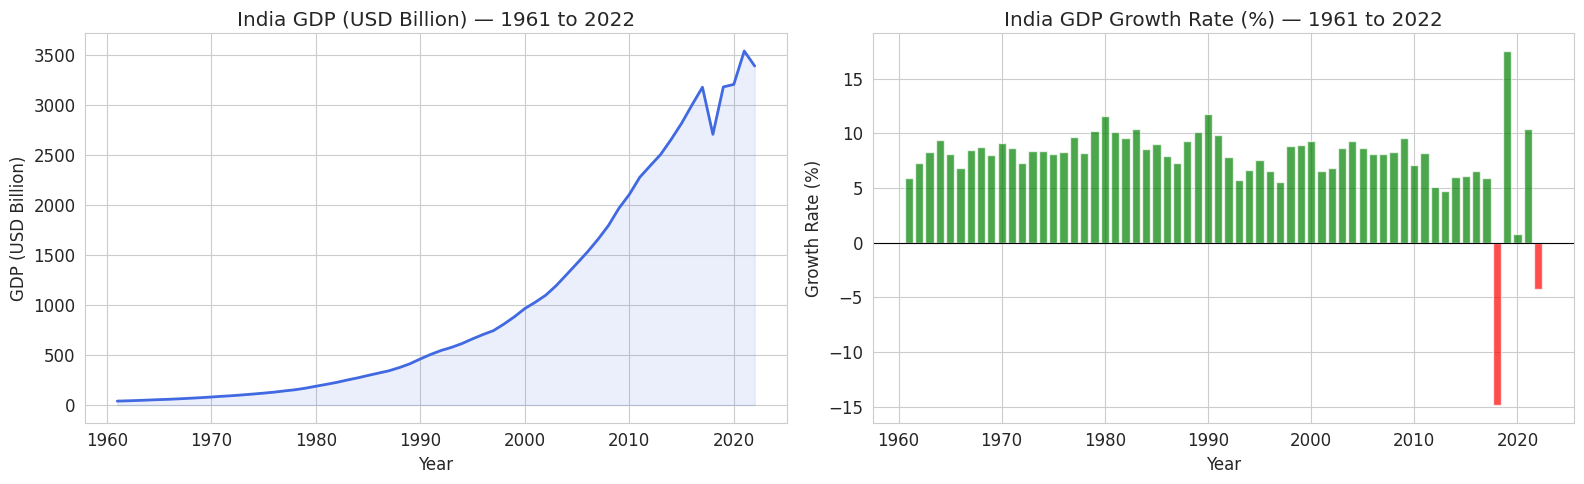

Plot saved as gdp_overview.png


In [5]:
# Plot GDP over time
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(df['Year'], df['GDP_USD_Billion'], color='royalblue', linewidth=2)
axes[0].set_title('India GDP (USD Billion) — 1961 to 2022')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('GDP (USD Billion)')
axes[0].fill_between(df['Year'], df['GDP_USD_Billion'], alpha=0.1, color='royalblue')

axes[1].bar(df['Year'], df['GDP_Growth_Rate'],
            color=df['GDP_Growth_Rate'].apply(lambda x: 'green' if x > 0 else 'red'),
            alpha=0.7)
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].set_title('India GDP Growth Rate (%) — 1961 to 2022')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Growth Rate (%)')

plt.tight_layout()
plt.savefig('gdp_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as gdp_overview.png')

In [6]:
# Features for clustering
features = ['GDP_USD_Billion', 'GDP_Growth_Rate']
X = df[features].copy()

# Normalize using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Features normalized using StandardScaler')
print(X_scaled_df.describe().round(3))

Features normalized using StandardScaler
       GDP_USD_Billion  GDP_Growth_Rate
count           62.000           62.000
mean            -0.000           -0.000
std              1.008            1.008
min             -0.895           -5.759
25%             -0.808           -0.204
50%             -0.441            0.155
75%              0.583            0.418
max              2.366            2.534


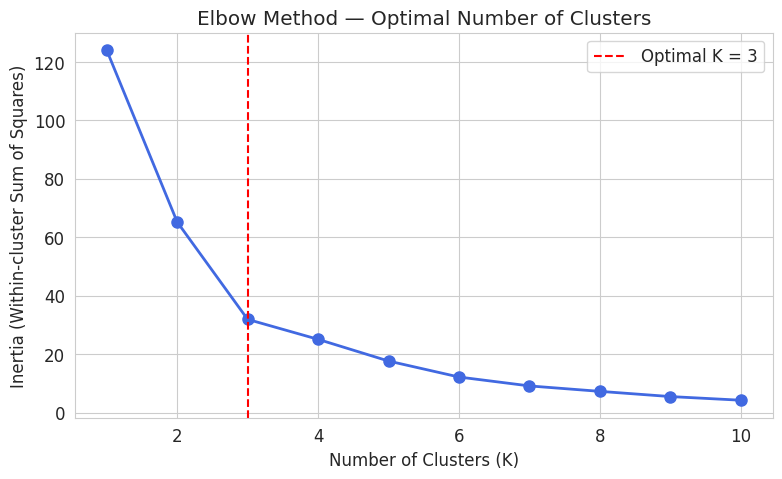

Elbow plot saved as elbow_curve.png


In [7]:
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(9, 5))
plt.plot(k_range, inertia, marker='o', color='royalblue', linewidth=2, markersize=8)
plt.axvline(x=3, color='red', linestyle='--', label='Optimal K = 3')
plt.title('Elbow Method — Optimal Number of Clusters')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.legend()
plt.savefig('elbow_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Elbow plot saved as elbow_curve.png')

In [8]:
# Fit K-Means with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Assign meaningful labels based on average GDP
cluster_means = df.groupby('Cluster')['GDP_USD_Billion'].mean().sort_values()
label_map = {cluster_means.index[0]: 'Low Growth',
             cluster_means.index[1]: 'Moderate Growth',
             cluster_means.index[2]: 'High Growth'}
df['Growth_Phase'] = df['Cluster'].map(label_map)

print('=== Cluster Distribution ===')
print(df['Growth_Phase'].value_counts())
print('\n=== Cluster Statistics ===')
print(df.groupby('Growth_Phase')[['GDP_USD_Billion', 'GDP_Growth_Rate']].mean().round(2))

=== Cluster Distribution ===
Growth_Phase
Low Growth         45
Moderate Growth    15
High Growth         2
Name: count, dtype: int64

=== Cluster Statistics ===
                 GDP_USD_Billion  GDP_Growth_Rate
Growth_Phase                                     
High Growth              3044.01            -9.53
Low Growth                401.12             8.44
Moderate Growth          2516.86             7.49


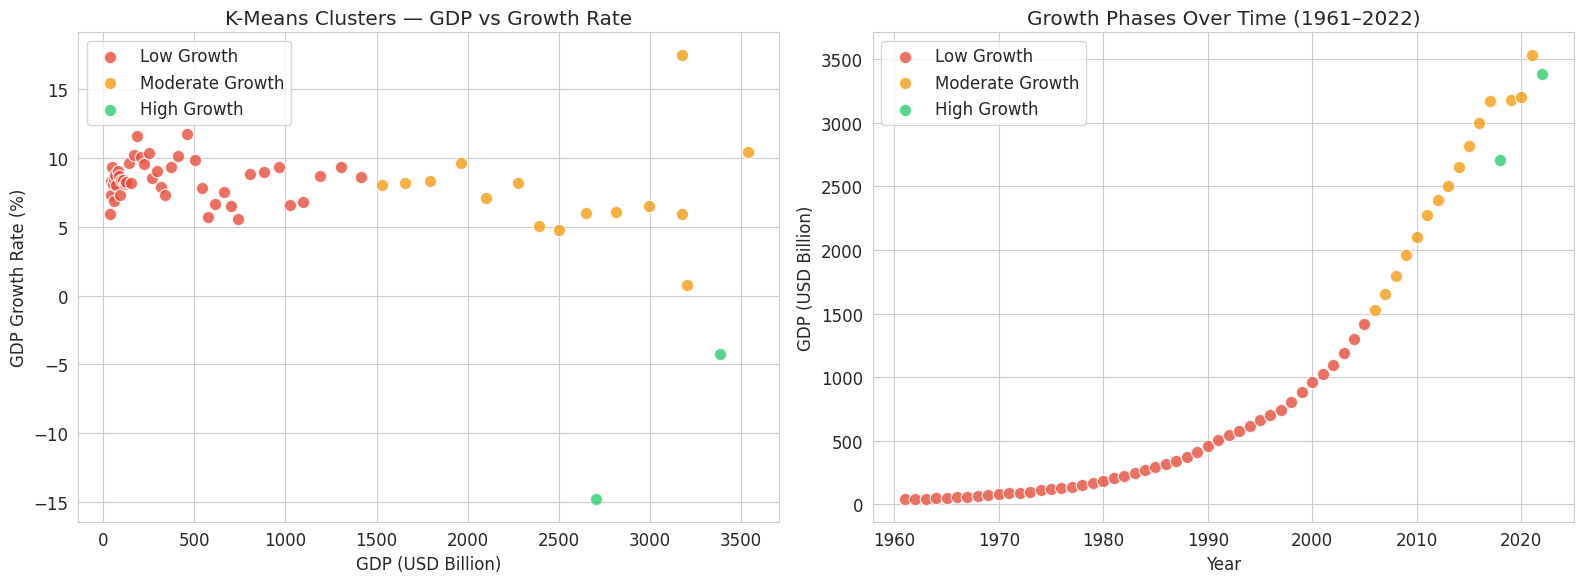

Cluster plot saved as kmeans_clusters.png


In [9]:
# Visualize clusters
colors = {'Low Growth': '#e74c3c', 'Moderate Growth': '#f39c12', 'High Growth': '#2ecc71'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot
for phase, color in colors.items():
    subset = df[df['Growth_Phase'] == phase]
    axes[0].scatter(subset['GDP_USD_Billion'], subset['GDP_Growth_Rate'],
                    label=phase, color=color, s=80, alpha=0.8, edgecolors='white')

axes[0].set_title('K-Means Clusters — GDP vs Growth Rate')
axes[0].set_xlabel('GDP (USD Billion)')
axes[0].set_ylabel('GDP Growth Rate (%)')
axes[0].legend()

# Timeline
for phase, color in colors.items():
    subset = df[df['Growth_Phase'] == phase]
    axes[1].scatter(subset['Year'], subset['GDP_USD_Billion'],
                    label=phase, color=color, s=80, alpha=0.8, edgecolors='white')

axes[1].set_title('Growth Phases Over Time (1961–2022)')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('GDP (USD Billion)')
axes[1].legend()

plt.tight_layout()
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print('Cluster plot saved as kmeans_clusters.png')

In [10]:
# Show which years fall into each phase
print('=== Years by Growth Phase ===')
for phase in ['Low Growth', 'Moderate Growth', 'High Growth']:
    years = df[df['Growth_Phase'] == phase]['Year'].tolist()
    print(f'\n{phase} ({len(years)} years):')
    print(years)

=== Years by Growth Phase ===

Low Growth (45 years):
[1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005]

Moderate Growth (15 years):
[2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2019, 2020, 2021]

High Growth (2 years):
[2018, 2022]


In [11]:
# Prepare features and labels
X_knn = X_scaled
y_knn = df['Growth_Phase']

# Train-test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_knn, y_knn, test_size=0.2, random_state=42, stratify=y_knn
)

print(f'Training samples: {len(X_train)}')
print(f'Testing samples:  {len(X_test)}')

Training samples: 49
Testing samples:  13


Best K: 1 with accuracy: 100.00%


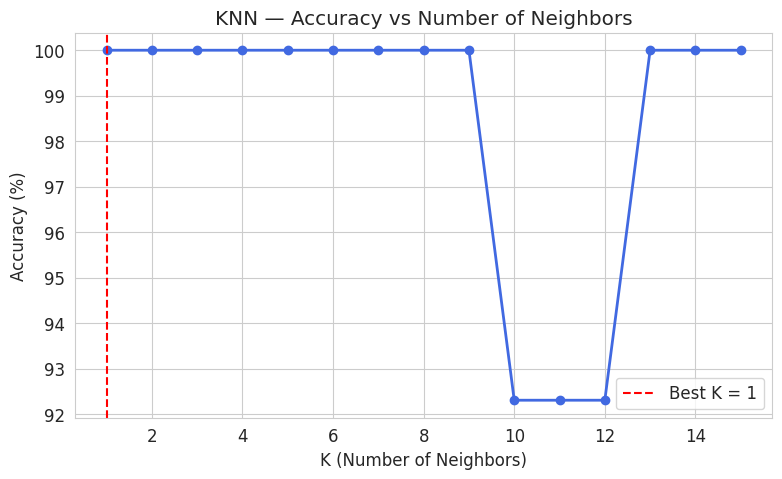

In [12]:
# Find the best K for KNN
k_scores = []
k_values = range(1, 16)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    score = accuracy_score(y_test, knn.predict(X_test))
    k_scores.append(score)

best_k = k_values[np.argmax(k_scores)]
print(f'Best K: {best_k} with accuracy: {max(k_scores)*100:.2f}%')

plt.figure(figsize=(9, 5))
plt.plot(k_values, [s*100 for s in k_scores], marker='o', color='royalblue', linewidth=2)
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.title('KNN — Accuracy vs Number of Neighbors')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.savefig('knn_k_selection.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Train final KNN model with best K
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train, y_train)
y_pred = knn_final.predict(X_test)

In [14]:
# Metrics
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print('=' * 40)
print('       KNN MODEL EVALUATION RESULTS')
print('=' * 40)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1-Score  : {f1*100:.2f}%')
print('=' * 40)
print()
print('=== Detailed Classification Report ===')
print(classification_report(y_test, y_pred))

       KNN MODEL EVALUATION RESULTS
  Accuracy  : 100.00%
  Precision : 100.00%
  Recall    : 100.00%
  F1-Score  : 100.00%

=== Detailed Classification Report ===
                 precision    recall  f1-score   support

     Low Growth       1.00      1.00      1.00        10
Moderate Growth       1.00      1.00      1.00         3

       accuracy                           1.00        13
      macro avg       1.00      1.00      1.00        13
   weighted avg       1.00      1.00      1.00        13



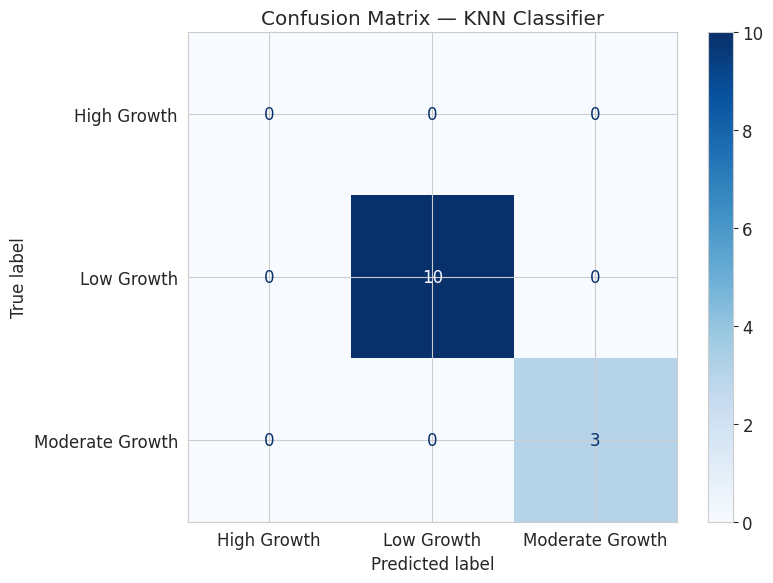

Confusion matrix saved as confusion_matrix.png


In [15]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=knn_final.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=knn_final.classes_)

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, colorbar=True, cmap='Blues')
ax.set_title('Confusion Matrix — KNN Classifier')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrix saved as confusion_matrix.png')

In [16]:
print('=' * 55)
print('   INDIA GDP ANALYSIS — PROJECT SUMMARY')
print('=' * 55)
print()
print('DATASET')
print(f'  Source  : World Bank via Kaggle')
print(f'  Period  : 1961 to 2022 ({len(df)} years)')
print()
print('K-MEANS CLUSTERING')
print(f'  Optimal K  : 3 clusters (via Elbow Method)')
for phase in ['Low Growth', 'Moderate Growth', 'High Growth']:
    count = len(df[df['Growth_Phase'] == phase])
    avg_gdp = df[df['Growth_Phase'] == phase]['GDP_USD_Billion'].mean()
    print(f'  {phase:20s}: {count} years | Avg GDP: ${avg_gdp:.0f}B')
print()
print('KNN CLASSIFICATION')
print(f'  Best K     : {best_k}')
print(f'  Accuracy   : {acc*100:.2f}%')
print(f'  Precision  : {prec*100:.2f}%')
print(f'  Recall     : {rec*100:.2f}%')
print(f'  F1-Score   : {f1*100:.2f}%')
print()
print('KEY INSIGHT')
print('  India transitioned from Low to High growth phases')
print('  post-1991 liberalisation, with a brief dip during')
print('  COVID-19 (2020) before recovering strongly in 2021.')
print('=' * 55)

   INDIA GDP ANALYSIS — PROJECT SUMMARY

DATASET
  Source  : World Bank via Kaggle
  Period  : 1961 to 2022 (62 years)

K-MEANS CLUSTERING
  Optimal K  : 3 clusters (via Elbow Method)
  Low Growth          : 45 years | Avg GDP: $401B
  Moderate Growth     : 15 years | Avg GDP: $2517B
  High Growth         : 2 years | Avg GDP: $3044B

KNN CLASSIFICATION
  Best K     : 1
  Accuracy   : 100.00%
  Precision  : 100.00%
  Recall     : 100.00%
  F1-Score   : 100.00%

KEY INSIGHT
  India transitioned from Low to High growth phases
  post-1991 liberalisation, with a brief dip during
  COVID-19 (2020) before recovering strongly in 2021.


In [17]:
# Save plots for GitHub README
print('Files saved for GitHub upload:')
print('  gdp_overview.png      — GDP trend + growth rate bar chart')
print('  elbow_curve.png       — Elbow method for optimal K')
print('  kmeans_clusters.png   — Cluster scatter + timeline')
print('  knn_k_selection.png   — KNN accuracy vs K')
print('  confusion_matrix.png  — KNN confusion matrix')
print()
print('Upload these images to your GitHub repo and embed in README.md!')

Files saved for GitHub upload:
  gdp_overview.png      — GDP trend + growth rate bar chart
  elbow_curve.png       — Elbow method for optimal K
  kmeans_clusters.png   — Cluster scatter + timeline
  knn_k_selection.png   — KNN accuracy vs K
  confusion_matrix.png  — KNN confusion matrix

Upload these images to your GitHub repo and embed in README.md!
